# Autoencoder + Classificador 4 Classes 

Este notebook testa uma alternativa aos modelos de transfer learning:

1. Pré-treino não supervisionado com **Denoising Convolutional Autoencoder**, usando imagens `Keep`, incluindo `Unlabelled`.
2. Aproveitamento do **encoder** como extrator de características.
3. Treino supervisionado para as 4 classes: `Biliary Leaks`, `Lithiasis`, `Stricture`, `Normal`.

Para testar só imagens tipo V no autoencoder, altera `AUTOENCODER_IMAGE_TYPES = ["V"]` na configuração.

In [1]:
# =========================
# 1. Imports e configuração
# =========================

import os
import gc
import json
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageEnhance, ImageFilter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
)

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation


In [2]:
# =========================
# 2. CONFIGURAÇÃO PRINCIPAL
# =========================

DATA_ROOT = Path('/mounts/mecd-ap-g5/data')
DATASET_DIR = DATA_ROOT / 'MIQR-CC-Dataset'
PROCESSED_IMAGES_DIR = DATASET_DIR / 'processed'
METADATA_PATH = DATASET_DIR / 'metadata.csv'

NOTEBOOK_NAME = 'autoencoder_pretrain_4class'
RESULTS_DIR = Path('/mounts/mecd-ap-g5/results') / NOTEBOOK_NAME
MODELS_DIR = Path('/mounts/mecd-ap-g5/models') / NOTEBOOK_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Imagem / dataloaders
IMG_SIZE = 224
BATCH_SIZE_AE = 32          # reduz para 16/8 se der OOM
BATCH_SIZE_CLS = 16         # reduz para 8/4 se der OOM
NUM_WORKERS = 4             # usa 0 se tiveres problemas
PIN_MEMORY = torch.cuda.is_available()

# Autoencoder
AE_EPOCHS = 20
AE_PATIENCE = 5
AE_LR = 1e-3
AE_WEIGHT_DECAY = 1e-5

# Classificador
CLS_EPOCHS_HEAD = 12
CLS_EPOCHS_FINETUNE = 20
CLS_PATIENCE = 6
LR_ENCODER = 1e-5
LR_HEAD = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
BASELINE_MACRO_F1 = 0.738

# None = usar todas as imagens Keep no autoencoder.
# Para testar só tipo V: AUTOENCODER_IMAGE_TYPES = ["V"]
AUTOENCODER_IMAGE_TYPES = None
# AUTOENCODER_IMAGE_TYPES = ["V"]

print('Metadata:', METADATA_PATH)
print('Images:', PROCESSED_IMAGES_DIR)
print('Results:', RESULTS_DIR)
print('Models:', MODELS_DIR)

Metadata: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/metadata.csv
Images: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/processed
Results: /mounts/mecd-ap-g5/results/autoencoder_pretrain_4class
Models: /mounts/mecd-ap-g5/models/autoencoder_pretrain_4class


In [3]:
# =========================
# 4. Carregamento dos metadados
# =========================

assert METADATA_PATH.exists(), f"METADATA_PATH não existe: {METADATA_PATH}"
assert PROCESSED_IMAGES_DIR.exists(), f"PROCESSED_IMAGES_DIR não existe: {PROCESSED_IMAGES_DIR}"

df = pd.read_csv(METADATA_PATH)
print("Shape original:", df.shape)
display(df.head())
print("Colunas:", df.columns.tolist())

label_col = "Label"
image_col = "processed_image_path"
patient_col = "patient_id"
keep_col = "Keep"
type_col = "image_type"

for col in [label_col, image_col, patient_col, keep_col]:
    assert col in df.columns, f"Coluna obrigatória não encontrada: {col}"

Shape original: (19317, 12)


,raw_image_path,processed_image_path,patient_id,image_type,sex,birth_date,exam_date,exam_time,age,equipment_model,Label,Keep
0,raw/1_image1.png,processed/1_image1.png,1,S,M,22/08/1952,03/02/2022,11:50:32,69.0,Ziehm Vision RFD,Unlabelled,Keep
1,raw/1_image2.png,processed/1_image2.png,1,S,M,22/08/1952,03/02/2022,11:47:43,69.0,Ziehm Vision RFD,Unlabelled,Keep
2,raw/1_image3.png,processed/1_image3.png,1,S,M,22/08/1952,03/02/2022,12:08:45,69.0,Ziehm Vision RFD,Unlabelled,Keep
3,raw/1_image4.png,processed/1_image4.png,1,S,M,22/08/1952,03/02/2022,11:50:22,69.0,Ziehm Vision RFD,Unlabelled,Keep
4,raw/2_image5.png,processed/2_image5.png,2,S,F,15/08/1925,21/06/2022,20:09:00,96.0,Ziehm Vision RFD,Lithiasis,Discard


Colunas: ['raw_image_path', 'processed_image_path', 'patient_id', 'image_type', 'sex', 'birth_date', 'exam_date', 'exam_time', 'age', 'equipment_model', 'Label', 'Keep']


In [4]:
# =========================
# 5. Resolver caminhos e preparar datasets AE / classificação
# =========================

df = df.copy()
df_keep = df[df[keep_col].astype(str).str.lower() == "keep"].copy()
print("Shape após Keep:", df_keep.shape)

def resolve_image_path(x):
    x = str(x)
    p = Path(x)
    if p.exists():
        return p
    p2 = DATASET_DIR / x
    if p2.exists():
        return p2
    p3 = PROCESSED_IMAGES_DIR / Path(x).name
    if p3.exists():
        return p3
    return None

df_keep["image_path"] = df_keep[image_col].apply(resolve_image_path)
missing_keep = df_keep["image_path"].isna().sum()
print(f"Imagens Keep encontradas: {len(df_keep) - missing_keep} / {len(df_keep)}")

df_keep = df_keep[df_keep["image_path"].notna()].copy()
df_keep["image_path"] = df_keep["image_path"].astype(str)

# Autoencoder: todas as Keep ou só tipo V
if AUTOENCODER_IMAGE_TYPES is not None:
    assert type_col in df_keep.columns, f"Não existe coluna {type_col}."
    df_ae = df_keep[df_keep[type_col].isin(AUTOENCODER_IMAGE_TYPES)].copy()
else:
    df_ae = df_keep.copy()

print("Dataset para autoencoder:", df_ae.shape)
if type_col in df_ae.columns:
    display(df_ae[type_col].value_counts())

# Dataset supervisionado: só labels úteis
invalid_labels = ["unlabelled", "unlabeled", "nan", "none", ""]
df_lab = df_keep[~df_keep[label_col].astype(str).str.lower().isin(invalid_labels)].copy()

def map_to_4_classes(label):
    label = str(label).strip()
    if label in ["Benign Stricture", "Malignant Stricture", "Stricture"]:
        return "Stricture"
    if label in ["Biliary Leaks", "Biliary_Leaks", "Bile Leaks"]:
        return "Biliary Leaks"
    if label in ["Lithiasis", "Stones", "Biliary lithiasis"]:
        return "Lithiasis"
    if label == "Normal":
        return "Normal"
    return None

df_lab["label"] = df_lab[label_col].apply(map_to_4_classes)
df_lab = df_lab[df_lab["label"].notna()].copy()

class_names = ["Biliary Leaks", "Lithiasis", "Stricture", "Normal"]
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df_lab["target"] = df_lab["label"].map(class_to_idx)

print("Dataset etiquetado:", df_lab.shape)
display(df_lab["label"].value_counts())
print("Pacientes etiquetados:", df_lab[patient_col].nunique())

Shape após Keep: (15216, 12)
Imagens Keep encontradas: 15216 / 15216
Dataset para autoencoder: (15216, 13)


image_type
S    14837
V      379
Name: count, dtype: int64

Dataset etiquetado: (1568, 15)


label
Lithiasis        726
Stricture        392
Normal           299
Biliary Leaks    151
Name: count, dtype: int64

Pacientes etiquetados: 436


In [6]:
# =========================
# 6. Split por paciente
# =========================

groups = df_lab[patient_col].astype(str).values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss1.split(df_lab, groups=groups))

train_df = df_lab.iloc[train_idx].copy()
temp_df = df_lab.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
temp_groups = temp_df[patient_col].astype(str).values
val_rel_idx, test_rel_idx = next(gss2.split(temp_df, groups=temp_groups))

val_df = temp_df.iloc[val_rel_idx].copy()
test_df = temp_df.iloc[test_rel_idx].copy()

def show_split(name, split_df):
    print(f"{name}: {split_df.shape[0]} imagens | {split_df[patient_col].nunique()} pacientes")
    display(split_df["label"].value_counts())

show_split("train", train_df)
show_split("val", val_df)
show_split("test", test_df)

train_df.to_csv(RESULTS_DIR / "train_split.csv", index=False)
val_df.to_csv(RESULTS_DIR / "val_split.csv", index=False)
test_df.to_csv(RESULTS_DIR / "test_split.csv", index=False)
df_ae.to_csv(RESULTS_DIR / "autoencoder_images.csv", index=False)

train: 1064 imagens | 305 pacientes


label
Lithiasis        507
Stricture        276
Normal           190
Biliary Leaks     91
Name: count, dtype: int64

val: 226 imagens | 65 pacientes


label
Lithiasis        106
Stricture         65
Normal            38
Biliary Leaks     17
Name: count, dtype: int64

test: 278 imagens | 66 pacientes


label
Lithiasis        113
Normal            71
Stricture         51
Biliary Leaks     43
Name: count, dtype: int64

In [7]:
# =========================
# 7. Datasets e transforms
# =========================

class DenoisingTransform:
    def __init__(self, p_noise=0.7, noise_std=0.08):
        self.p_noise = p_noise
        self.noise_std = noise_std
        self.to_tensor = T.ToTensor()

    def __call__(self, pil_img):
        target = self.to_tensor(pil_img)
        img = pil_img.copy()
        if random.random() < 0.5:
            img = ImageEnhance.Contrast(img).enhance(random.uniform(0.75, 1.25))
        if random.random() < 0.3:
            img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 1.0)))
        corrupted = self.to_tensor(img)
        if random.random() < self.p_noise:
            corrupted = torch.clamp(corrupted + torch.randn_like(corrupted) * self.noise_std, 0.0, 1.0)
        return corrupted, target


ae_transform = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    DenoisingTransform(p_noise=0.7, noise_std=0.08),
])

cls_train_transform = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomApply([T.RandomRotation(degrees=8)], p=0.5),
    T.RandomApply([T.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05))], p=0.5),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.2),
    T.ToTensor(),
])

cls_eval_transform = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
])

class AutoencoderDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "image_path"]).convert("L")
        return self.transform(img)

class ClassificationDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img = Image.open(row["image_path"]).convert("L")
        x = self.transform(img)
        y = int(row["target"])
        return x, y

In [8]:
# =========================
# 8. Dataloaders
# =========================

ae_dataset = AutoencoderDataset(df_ae, transform=ae_transform)
ae_groups = df_ae[patient_col].astype(str).values if patient_col in df_ae.columns else np.arange(len(df_ae))
gss_ae = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
ae_train_idx, ae_val_idx = next(gss_ae.split(df_ae, groups=ae_groups))

ae_train_ds = torch.utils.data.Subset(ae_dataset, ae_train_idx)
ae_val_ds = torch.utils.data.Subset(ae_dataset, ae_val_idx)

ae_train_loader = DataLoader(ae_train_ds, batch_size=BATCH_SIZE_AE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
ae_val_loader = DataLoader(ae_val_ds, batch_size=BATCH_SIZE_AE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

train_dataset = ClassificationDataset(train_df, cls_train_transform)
val_dataset = ClassificationDataset(val_df, cls_eval_transform)
test_dataset = ClassificationDataset(test_df, cls_eval_transform)

class_counts = train_df["target"].value_counts().sort_index()
class_weights_np = len(train_df) / (len(class_names) * class_counts.values)
sample_weights = train_df["target"].map(lambda x: class_weights_np[int(x)]).values
sampler = WeightedRandomSampler(weights=torch.DoubleTensor(sample_weights), num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_CLS, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_CLS, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE_CLS, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("AE train batches:", len(ae_train_loader))
print("CLS train batches:", len(train_loader))

AE train batches: 402
CLS train batches: 67


In [9]:
# =========================
# 9. Modelo: Denoising Convolutional Autoencoder
# =========================

class ConvEncoder(nn.Module):
    def __init__(self, in_channels=1, base=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, base, 3, 2, 1), nn.BatchNorm2d(base), nn.ReLU(inplace=False),
            nn.Conv2d(base, base*2, 3, 2, 1), nn.BatchNorm2d(base*2), nn.ReLU(inplace=False),
            nn.Conv2d(base*2, base*4, 3, 2, 1), nn.BatchNorm2d(base*4), nn.ReLU(inplace=False),
            nn.Conv2d(base*4, base*8, 3, 2, 1), nn.BatchNorm2d(base*8), nn.ReLU(inplace=False),
            nn.Conv2d(base*8, base*16, 3, 2, 1), nn.BatchNorm2d(base*16), nn.ReLU(inplace=False),
        )
        self.out_channels = base * 16
    def forward(self, x):
        return self.net(x)

class ConvDecoder(nn.Module):
    def __init__(self, out_channels=1, base=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(base*16, base*8, 4, 2, 1), nn.BatchNorm2d(base*8), nn.ReLU(inplace=False),
            nn.ConvTranspose2d(base*8, base*4, 4, 2, 1), nn.BatchNorm2d(base*4), nn.ReLU(inplace=False),
            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1), nn.BatchNorm2d(base*2), nn.ReLU(inplace=False),
            nn.ConvTranspose2d(base*2, base, 4, 2, 1), nn.BatchNorm2d(base), nn.ReLU(inplace=False),
            nn.ConvTranspose2d(base, out_channels, 4, 2, 1), nn.Sigmoid(),
        )
    def forward(self, z):
        return self.net(z)

class DenoisingAutoencoder(nn.Module):
    def __init__(self, base=32):
        super().__init__()
        self.encoder = ConvEncoder(1, base)
        self.decoder = ConvDecoder(1, base)
    def forward(self, x):
        return self.decoder(self.encoder(x))

#ae_model = DenoisingAutoencoder(base=32).to(device)
# Se der OOM, muda base=16
AE_BASE = 32
ae_model = DenoisingAutoencoder(base=AE_BASE).to(device)
print(ae_model)

DenoisingAutoencoder(
  (encoder): ConvEncoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): ReLU()
      (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

In [11]:
# =========================
# 10. Treino do Autoencoder
# =========================

def train_autoencoder(model, train_loader, val_loader):
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=AE_LR, weight_decay=AE_WEIGHT_DECAY)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    best_val = float("inf")
    best_path = MODELS_DIR / "best_denoising_autoencoder.pt"
    history = []
    patience_counter = 0

    for epoch in range(1, AE_EPOCHS + 1):
        model.train()
        train_losses = []
        for corrupted, target in train_loader:
            corrupted = corrupted.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                recon = model(corrupted)
                loss = criterion(recon, target)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for corrupted, target in val_loader:
                corrupted = corrupted.to(device, non_blocking=True)
                target = target.to(device, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    recon = model(corrupted)
                    loss = criterion(recon, target)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append({"epoch": epoch, "train_mse": train_loss, "val_mse": val_loss})
        print(f"[AE] Epoch {epoch:02d}/{AE_EPOCHS} | train MSE={train_loss:.5f} | val MSE={val_loss:.5f}")

        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
            print("  -> Novo melhor AE guardado")
        else:
            patience_counter += 1
        if patience_counter >= AE_PATIENCE:
            print("Early stopping AE.")
            break

    pd.DataFrame(history).to_csv(RESULTS_DIR / "autoencoder_history.csv", index=False)
    model.load_state_dict(torch.load(best_path, map_location=device))
    return model, history

ae_model, ae_history = train_autoencoder(ae_model, ae_train_loader, ae_val_loader)

/tmp/ipykernel_293805/162374612.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_293805/162374612.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_293805/162374612.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[AE] Epoch 01/20 | train MSE=0.00059 | val MSE=0.00059
  -> Novo melhor AE guardado
[AE] Epoch 02/20 | train MSE=0.00055 | val MSE=0.00050
  -> Novo melhor AE guardado
[AE] Epoch 03/20 | train MSE=0.00055 | val MSE=0.00050
[AE] Epoch 04/20 | train MSE=0.00053 | val MSE=0.00048
  -> Novo melhor AE guardado
[AE] Epoch 05/20 | train MSE=0.00052 | val MSE=0.00056
[AE] Epoch 06/20 | train MSE=0.00051 | val MSE=0.00046
  -> Novo melhor AE guardado
[AE] Epoch 07/20 | train MSE=0.00049 | val MSE=0.00046
[AE] Epoch 08/20 | train MSE=0.00049 | val MSE=0.00048
[AE] Epoch 09/20 | train MSE=0.00049 | val MSE=0.00055
[AE] Epoch 10/20 | train MSE=0.00048 | val MSE=0.00047
[AE] Epoch 11/20 | train MSE=0.00046 | val MSE=0.00044
  -> Novo melhor AE guardado
[AE] Epoch 12/20 | train MSE=0.00046 | val MSE=0.00044
[AE] Epoch 13/20 | train MSE=0.00044 | val MSE=0.00043
  -> Novo melhor AE guardado
[AE] Epoch 14/20 | train MSE=0.00044 | val MSE=0.00047
[AE] Epoch 15/20 | train MSE=0.00044 | val MSE=0.00044
[

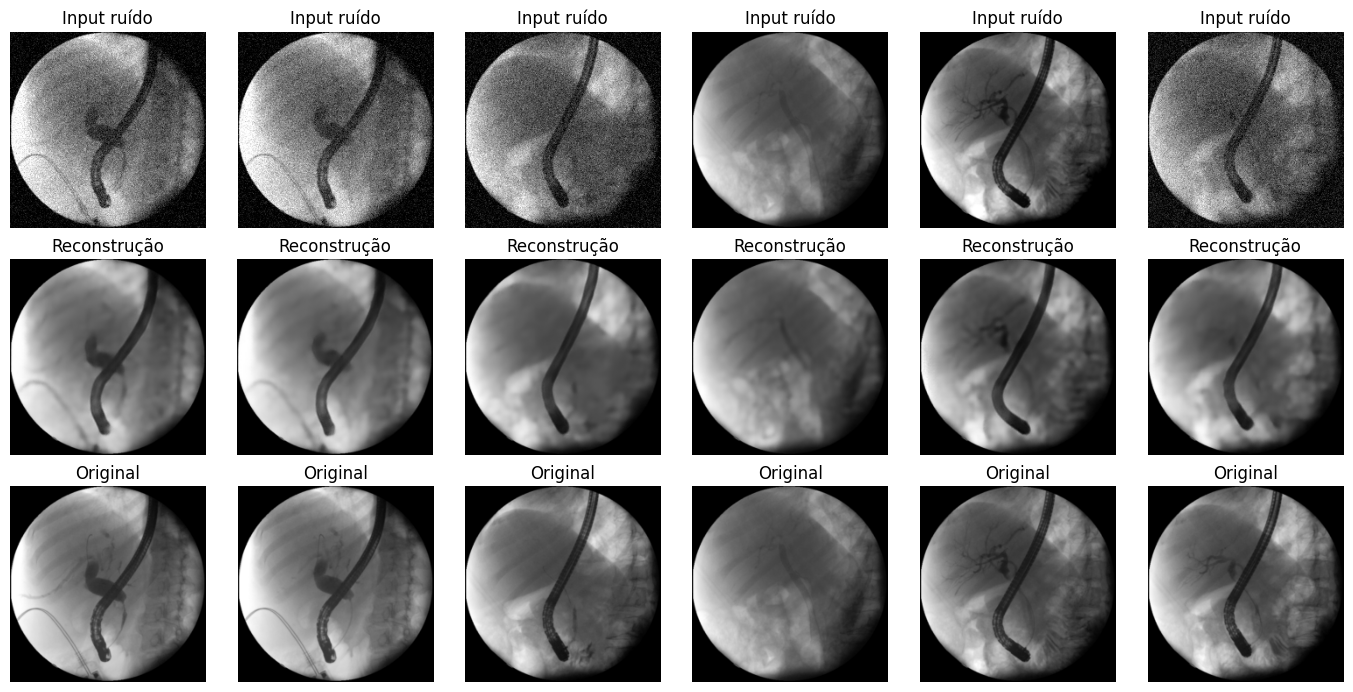

Guardado em: /mounts/mecd-ap-g5/results/autoencoder_pretrain_4class/autoencoder_reconstructions.png


In [12]:
# =========================
# 11. Visualizar reconstruções
# =========================

def show_reconstructions(model, loader, n=6):
    model.eval()
    corrupted, target = next(iter(loader))
    corrupted = corrupted[:n].to(device)
    target = target[:n].to(device)
    with torch.no_grad():
        recon = model(corrupted)
    corrupted = corrupted.cpu(); target = target.cpu(); recon = recon.cpu()
    fig, axes = plt.subplots(3, n, figsize=(2.3*n, 7))
    for i in range(n):
        axes[0, i].imshow(corrupted[i, 0], cmap="gray"); axes[0, i].set_title("Input ruído"); axes[0, i].axis("off")
        axes[1, i].imshow(recon[i, 0], cmap="gray"); axes[1, i].set_title("Reconstrução"); axes[1, i].axis("off")
        axes[2, i].imshow(target[i, 0], cmap="gray"); axes[2, i].set_title("Original"); axes[2, i].axis("off")
    plt.tight_layout()
    out_path = RESULTS_DIR / "autoencoder_reconstructions.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Guardado em:", out_path)

show_reconstructions(ae_model, ae_val_loader, n=6)

In [13]:
# =========================
# 12. Classificador com encoder pré-treinado
# =========================

class EncoderClassifier(nn.Module):
    def __init__(self, encoder, num_classes=4, dropout=0.4):
        super().__init__()
        self.encoder = encoder
        in_channels = encoder.out_channels
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_channels, 256),
            nn.ReLU(inplace=False),
            nn.BatchNorm1d(256),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        z = self.encoder(x)
        z = self.pool(z).flatten(1)
        return self.classifier(z)

classifier_model = EncoderClassifier(ae_model.encoder, num_classes=len(class_names), dropout=0.4).to(device)
print(classifier_model)

EncoderClassifier(
  (encoder): ConvEncoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): ReLU()
      (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (14

In [15]:
# =========================
# 13. Funções de treino e avaliação do classificador
# =========================

def evaluate_classifier(model, loader, split_name="val"):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    metrics = {
        f"{split_name}_accuracy": accuracy_score(y_true, y_pred),
        f"{split_name}_balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        f"{split_name}_macro_f1": f1_score(y_true, y_pred, average="macro"),
    }
    try:
        y_onehot = np.eye(len(class_names))[y_true]
        metrics[f"{split_name}_roc_auc_macro_ovr"] = roc_auc_score(y_onehot, y_prob, average="macro", multi_class="ovr")
    except Exception as e:
        metrics[f"{split_name}_roc_auc_macro_ovr"] = np.nan
        print(f"Aviso ROC-AUC {split_name}: {e}")
    try:
        y_onehot = np.eye(len(class_names))[y_true]
        metrics[f"{split_name}_pr_auc_macro"] = average_precision_score(y_onehot, y_prob, average="macro")
    except Exception as e:
        metrics[f"{split_name}_pr_auc_macro"] = np.nan
        print(f"Aviso PR-AUC {split_name}: {e}")
    return metrics, y_true, y_pred, y_prob


def set_encoder_trainable(model, trainable):
    for p in model.encoder.parameters():
        p.requires_grad = trainable


def train_classifier_phase(model, train_loader, val_loader, phase_name, epochs, encoder_trainable):
    set_encoder_trainable(model, encoder_trainable)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    if encoder_trainable:
        optimizer = torch.optim.AdamW([
            {"params": model.encoder.parameters(), "lr": LR_ENCODER},
            {"params": model.classifier.parameters(), "lr": LR_HEAD},
        ], weight_decay=WEIGHT_DECAY)
    else:
        optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    best_val_f1 = -1
    best_path = MODELS_DIR / f"best_classifier_{phase_name}.pt"
    patience_counter = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_losses.append(loss.item())

        val_metrics, _, _, _ = evaluate_classifier(model, val_loader, split_name="val")
        val_f1 = val_metrics["val_macro_f1"]
        scheduler.step(val_f1)
        row = {"phase": phase_name, "epoch": epoch, "train_loss": float(np.mean(train_losses)), **val_metrics}
        history.append(row)
        print(f"[{phase_name}] Epoch {epoch:02d}/{epochs} | loss={row['train_loss']:.4f} | val macro F1={val_f1:.4f} | val bal acc={val_metrics['val_balanced_accuracy']:.4f}")
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
            print("  -> Novo melhor classificador guardado")
        else:
            patience_counter += 1
        if patience_counter >= CLS_PATIENCE:
            print(f"Early stopping {phase_name}.")
            break
    pd.DataFrame(history).to_csv(RESULTS_DIR / f"classifier_history_{phase_name}.csv", index=False)
    model.load_state_dict(torch.load(best_path, map_location=device))
    return model, history, best_val_f1

In [17]:
# =========================
# 14. Treino supervisionado — Fase 1: encoder congelado
# =========================

classifier_model, hist_head, best_head_f1 = train_classifier_phase(
    classifier_model,
    train_loader,
    val_loader,
    phase_name="head_frozen_encoder",
    epochs=CLS_EPOCHS_HEAD,
    encoder_trainable=False,
)
print("Melhor val macro F1 fase cabeça:", best_head_f1)


/tmp/ipykernel_293805/2792064256.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_293805/2792064256.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[head_frozen_encoder] Epoch 01/12 | loss=1.4054 | val macro F1=0.1656 | val bal acc=0.2396
  -> Novo melhor classificador guardado


/tmp/ipykernel_293805/2792064256.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[head_frozen_encoder] Epoch 02/12 | loss=1.3794 | val macro F1=0.1684 | val bal acc=0.2007
  -> Novo melhor classificador guardado


/tmp/ipykernel_293805/2792064256.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


...

[head_frozen_encoder] Epoch 10/12 | loss=1.3600 | val macro F1=0.1368 | val bal acc=0.1666


/tmp/ipykernel_293805/2792064256.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[head_frozen_encoder] Epoch 11/12 | loss=1.3448 | val macro F1=0.1898 | val bal acc=0.2039


/tmp/ipykernel_293805/2792064256.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[head_frozen_encoder] Epoch 12/12 | loss=1.3813 | val macro F1=0.2008 | val bal acc=0.2204
Early stopping head_frozen_encoder.
Melhor val macro F1 fase cabeça: 0.209986001355336


In [18]:
# =========================
# 15. Treino supervisionado — Fase 2: fine-tuning do encoder
# =========================

classifier_model, hist_ft, best_ft_f1 = train_classifier_phase(
    classifier_model,
    train_loader,
    val_loader,
    phase_name="finetune_encoder",
    epochs=CLS_EPOCHS_FINETUNE,
    encoder_trainable=True,
)
print("Melhor val macro F1 fine-tuning:", best_ft_f1)
final_model_path = MODELS_DIR / "autoencoder_encoder_classifier_final.pt"
torch.save(classifier_model.state_dict(), final_model_path)
print("Modelo final guardado em:", final_model_path)

/tmp/ipykernel_293805/2792064256.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_293805/2792064256.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[finetune_encoder] Epoch 01/20 | loss=1.3536 | val macro F1=0.1961 | val bal acc=0.2141
  -> Novo melhor classificador guardado


/tmp/ipykernel_293805/2792064256.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[finetune_encoder] Epoch 02/20 | loss=1.3808 | val macro F1=0.1916 | val bal acc=0.2044


/tmp/ipykernel_293805/2792064256.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


...

[finetune_encoder] Epoch 09/20 | loss=1.3557 | val macro F1=0.2097 | val bal acc=0.2775


/tmp/ipykernel_293805/2792064256.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[finetune_encoder] Epoch 10/20 | loss=1.3381 | val macro F1=0.1914 | val bal acc=0.2373


/tmp/ipykernel_293805/2792064256.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[finetune_encoder] Epoch 11/20 | loss=1.3326 | val macro F1=0.2221 | val bal acc=0.2471
Early stopping finetune_encoder.
Melhor val macro F1 fine-tuning: 0.23374573977005544
Modelo final guardado em: /mounts/mecd-ap-g5/models/autoencoder_pretrain_4class/autoencoder_encoder_classifier_final.pt


In [19]:
# =========================
# 16. Avaliação final no teste
# =========================

test_metrics, y_true, y_pred, y_prob = evaluate_classifier(classifier_model, test_loader, split_name="test")
print(json.dumps(test_metrics, indent=2))

report = classification_report(y_true, y_pred, target_names=class_names, digits=4, output_dict=True)
report_df = pd.DataFrame(report).transpose()
display(report_df)
report_df.to_csv(RESULTS_DIR / "classification_report_test.csv")

summary = {**test_metrics, "baseline_macro_f1": BASELINE_MACRO_F1, "difference_to_baseline": test_metrics["test_macro_f1"] - BASELINE_MACRO_F1}
summary_df = pd.DataFrame([summary])
display(summary_df)
summary_df.to_csv(RESULTS_DIR / "test_summary.csv", index=False)

{
  "test_accuracy": 0.3129496402877698,
  "test_balanced_accuracy": 0.299726137900731,
  "test_macro_f1": 0.27396214480172504,
  "test_roc_auc_macro_ovr": 0.5795255587531853,
  "test_pr_auc_macro": 0.30338563377315386
}


,precision,recall,f1-score,support
Biliary Leaks,0.283582,0.441860,0.345455,43.00000
Lithiasis,0.472222,0.451327,0.461538,113.00000
Stricture,0.137931,0.235294,0.173913,51.00000
Normal,0.312500,0.070423,0.114943,71.00000
accuracy,0.312950,0.312950,0.312950,0.31295
macro avg,0.301559,0.299726,0.273962,278.00000
weighted avg,0.340925,0.312950,0.302298,278.00000


,test_accuracy,test_balanced_accuracy,test_macro_f1,test_roc_auc_macro_ovr,test_pr_auc_macro,baseline_macro_f1,difference_to_baseline
0,0.31295,0.299726,0.273962,0.579526,0.303386,0.738,-0.464038


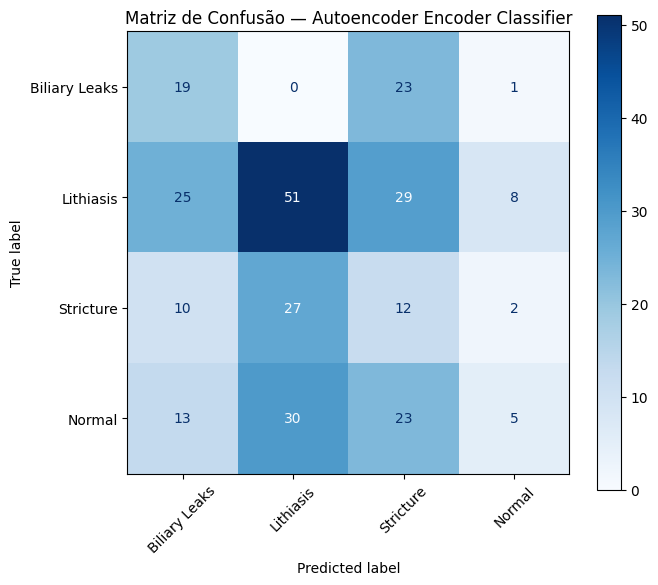

Guardado em: /mounts/mecd-ap-g5/results/autoencoder_pretrain_4class/confusion_matrix_test.png


In [20]:
# =========================
# 17. Matriz de confusão
# =========================

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Matriz de Confusão — Autoencoder Encoder Classifier")
plt.tight_layout()
out_path = RESULTS_DIR / "confusion_matrix_test.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado em:", out_path)

,phase,epoch,train_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,val_roc_auc_macro_ovr,val_pr_auc_macro,global_epoch
18,finetune_encoder,7,1.359413,0.278761,0.251766,0.230008,0.470367,0.273876,19
19,finetune_encoder,8,1.359715,0.221239,0.268501,0.217371,0.465473,0.280255,20
20,finetune_encoder,9,1.355679,0.247788,0.277468,0.209669,0.461371,0.283051,21
21,finetune_encoder,10,1.338083,0.199115,0.237337,0.191404,0.460960,0.280328,22
22,finetune_encoder,11,1.332637,0.243363,0.247086,0.222069,0.446881,0.276377,23


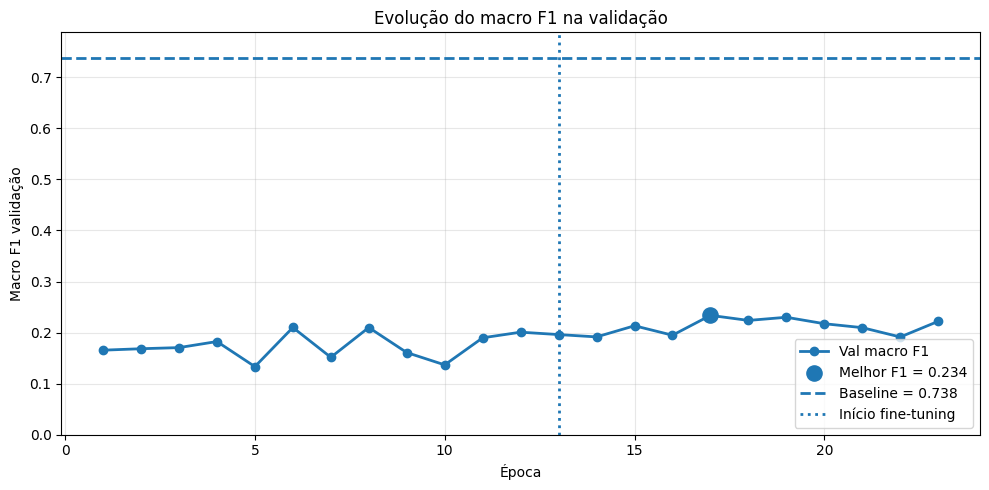

Guardado em: /mounts/mecd-ap-g5/results/autoencoder_pretrain_4class/training_val_macro_f1_improved.png


In [22]:
# =========================
# 18. Curvas de treino melhoradas
# =========================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

hist_df = pd.concat(
    [pd.DataFrame(hist_head), pd.DataFrame(hist_ft)],
    ignore_index=True
)

hist_df.to_csv(RESULTS_DIR / "classifier_history_all.csv", index=False)

# Criar época contínua para não sobrepor head e fine-tuning
hist_df["global_epoch"] = np.arange(1, len(hist_df) + 1)

display(hist_df.tail())

# Identificar início do fine-tuning
phase_change_epoch = None
if "phase" in hist_df.columns and hist_df["phase"].nunique() > 1:
    first_phase = hist_df["phase"].iloc[0]
    change_rows = hist_df[hist_df["phase"] != first_phase]
    if len(change_rows) > 0:
        phase_change_epoch = change_rows["global_epoch"].iloc[0]

best_idx = hist_df["val_macro_f1"].idxmax()
best_epoch = hist_df.loc[best_idx, "global_epoch"]
best_f1 = hist_df.loc[best_idx, "val_macro_f1"]

# =========================
# Gráfico 1: Macro F1
# =========================

plt.figure(figsize=(10, 5))

plt.plot(
    hist_df["global_epoch"],
    hist_df["val_macro_f1"],
    marker="o",
    linewidth=2,
    label="Val macro F1"
)

plt.scatter(
    best_epoch,
    best_f1,
    s=120,
    zorder=5,
    label=f"Melhor F1 = {best_f1:.3f}"
)

plt.axhline(
    BASELINE_MACRO_F1,
    linestyle="--",
    linewidth=2,
    label=f"Baseline = {BASELINE_MACRO_F1:.3f}"
)

if phase_change_epoch is not None:
    plt.axvline(
        phase_change_epoch,
        linestyle=":",
        linewidth=2,
        label="Início fine-tuning"
    )

plt.xlabel("Época")
plt.ylabel("Macro F1 validação")
plt.title("Evolução do macro F1 na validação")
plt.ylim(0, max(BASELINE_MACRO_F1 + 0.05, hist_df["val_macro_f1"].max() + 0.1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_path = RESULTS_DIR / "training_val_macro_f1_improved.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Guardado em:", out_path)

In [ ]:
# =========================
# 19. Grad-CAM simples para o encoder CNN
# =========================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.fwd_hook = target_layer.register_forward_hook(self._save_activation)
        self.bwd_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach().clone()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        score = logits[:, class_idx].sum()
        score.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = F.relu(cam)
        cam = F.interpolate(cam.unsqueeze(1), size=x.shape[2:], mode="bilinear", align_corners=False).squeeze(1)
        cam = cam[0].detach().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam, logits.detach()

    def close(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()


def show_gradcam_examples(model, dataset, n_per_class=2):
    clean_cuda()
    model.eval()
    target_layer = model.encoder.net[-3]
    gradcam = GradCAM(model, target_layer)
    indices_by_class = defaultdict(list)
    for i in range(len(dataset)):
        _, label = dataset[i]
        indices_by_class[int(label)].append(i)
    selected = []
    rng = random.Random(SEED)
    for c in range(len(class_names)):
        inds = indices_by_class[c]
        rng.shuffle(inds)
        selected.extend(inds[:n_per_class])
    n = len(selected)
    fig, axes = plt.subplots(n, 3, figsize=(10, 3*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)
    for row_i, idx in enumerate(selected):
        img_tensor, true_label = dataset[idx]
        x = img_tensor.unsqueeze(0).to(device)
        cam, logits = gradcam(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_label = int(np.argmax(probs))
        img_np = img_tensor[0].cpu().numpy()
        axes[row_i, 0].imshow(img_np, cmap="gray")
        axes[row_i, 0].set_title(f"Original
True: {class_names[true_label]}")
        axes[row_i, 0].axis("off")
        axes[row_i, 1].imshow(cam, cmap="jet")
        axes[row_i, 1].set_title("Grad-CAM")
        axes[row_i, 1].axis("off")
        axes[row_i, 2].imshow(img_np, cmap="gray")
        axes[row_i, 2].imshow(cam, cmap="jet", alpha=0.45)
        axes[row_i, 2].set_title(f"Overlay
Pred: {class_names[pred_label]} ({probs[pred_label]:.2f})")
        axes[row_i, 2].axis("off")
    plt.tight_layout()
    out_path = RESULTS_DIR / "gradcam_examples.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    gradcam.close()
    print("Guardado em:", out_path)

show_gradcam_examples(classifier_model, test_dataset, n_per_class=2)

In [ ]:
# =========================
# 20. Guardar configuração final
# =========================

config = {
    "DATA_ROOT": str(DATA_ROOT),
    "DATASET_DIR": str(DATASET_DIR),
    "PROCESSED_IMAGES_DIR": str(PROCESSED_IMAGES_DIR),
    "METADATA_PATH": str(METADATA_PATH),
    "NOTEBOOK_NAME": NOTEBOOK_NAME,
    "IMG_SIZE": IMG_SIZE,
    "BATCH_SIZE_AE": BATCH_SIZE_AE,
    "BATCH_SIZE_CLS": BATCH_SIZE_CLS,
    "AE_BASE": AE_BASE,
    "AE_EPOCHS": AE_EPOCHS,
    "CLS_EPOCHS_HEAD": CLS_EPOCHS_HEAD,
    "CLS_EPOCHS_FINETUNE": CLS_EPOCHS_FINETUNE,
    "AUTOENCODER_IMAGE_TYPES": AUTOENCODER_IMAGE_TYPES,
    "class_names": class_names,
    "BASELINE_MACRO_F1": BASELINE_MACRO_F1,
}
with open(RESULTS_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)
print("Configuração guardada em:", RESULTS_DIR / "config.json")
print("Fim.")